# 05 - Time Series Feature Engineering

This notebook creates the modeling table for one-month-ahead forecasting. Each row is a business at feature month `t`; the target is review count in month `t + 1`.

All features are computed using information available up to month `t`. January 2022 is excluded because it is a partial month.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "feature_engineering"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
FEATURE_SUMMARY_PATH = PROCESSED_DIR / "forecasting_feature_summary.json"

MIN_TOTAL_REVIEWS = 100
MIN_ACTIVE_MONTHS = 36
MODELING_START = pd.Period("2015-01", freq="M")
MODELING_END_FEATURE = pd.Period("2021-11", freq="M")
EXCLUDED_PARTIAL_MONTH = "2022-01"

pd.set_option("display.max_columns", 80)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(PROJECT_ROOT)

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp


In [2]:
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

def has_category(categories, keywords):
    text = str(categories).lower()
    return int(any(keyword in text for keyword in keywords))

In [3]:
businesses = pd.DataFrame([
    {
        "business_id": r["business_id"],
        "name": r.get("name"),
        "business_stars": r.get("stars"),
        "business_review_count": r.get("review_count"),
        "categories": r.get("categories") or "",
    }
    for r in iter_jsonl(BUSINESSES_PATH)
])

review_rows = []
for r in iter_jsonl(REVIEWS_PATH):
    review_rows.append({"review_id": r["review_id"], "business_id": r["business_id"], "user_id": r["user_id"], "stars": float(r["stars"]), "date": r["date"]})
reviews = pd.DataFrame(review_rows)
reviews["date"] = pd.to_datetime(reviews["date"])
reviews["month"] = reviews["date"].dt.to_period("M")
reviews = reviews[reviews["month"].astype(str) != EXCLUDED_PARTIAL_MONTH].copy()

print("businesses", businesses.shape)
print("reviews", reviews.shape, reviews["month"].min(), reviews["month"].max())

businesses (6215, 5)
reviews (633299, 6) 2005-03 2021-12


In [4]:
monthly_counts = reviews.groupby(["business_id", "month"]).size().rename("monthly_review_count").reset_index()
business_activity = monthly_counts.groupby("business_id").agg(total_reviews=("monthly_review_count", "sum"), active_months=("month", "nunique")).reset_index()

cohort = business_activity[(business_activity["total_reviews"] >= MIN_TOTAL_REVIEWS) & (business_activity["active_months"] >= MIN_ACTIVE_MONTHS)].copy()
cohort = cohort.merge(businesses, on="business_id", how="left")
cohort.to_csv(COHORT_BUSINESSES_PATH, index=False)
cohort_ids = cohort["business_id"].tolist()

print(f"Forecasting cohort businesses: {len(cohort_ids):,}")
cohort[["business_id", "name", "total_reviews", "active_months"]].head()

Forecasting cohort businesses: 1,151


,business_id,name,total_reviews,active_months
0,-1XSzguS6XLN-V6MVZMg2A,Restaurant Rebirth,528,71
1,-9ZNA22YhFlvTdLDYjvNdA,Cathedral-Basilica of St. Louis King of France,202,100
2,-A2OLubXDsMRPNN7LqohPA,Rollin Fatties,176,65
3,-AaxZJ_I4rSFOBJbBz4SlQ,Hansen's Sno-Bliz,519,125
4,-HUDQ5eek6Edz3zuNrE4jw,Staybridge Suites New Orleans French Qtr/Dwtn,116,71


In [5]:
all_months = pd.period_range(reviews["month"].min(), pd.Period("2021-12", freq="M"), freq="M")
index = pd.MultiIndex.from_product([cohort_ids, all_months], names=["business_id", "feature_month"])
panel = pd.DataFrame(index=index).reset_index()

monthly_star_stats = (
    reviews[reviews["business_id"].isin(cohort_ids)]
    .groupby(["business_id", "month"])
    .agg(monthly_review_count=("review_id", "size"), monthly_star_sum=("stars", "sum"))
    .reset_index()
    .rename(columns={"month": "feature_month"})
)

panel = panel.merge(monthly_star_stats, on=["business_id", "feature_month"], how="left")
panel["monthly_review_count"] = panel["monthly_review_count"].fillna(0).astype(int)
panel["monthly_star_sum"] = panel["monthly_star_sum"].fillna(0.0)
panel = panel.sort_values(["business_id", "feature_month"])

by_business = panel.groupby("business_id", group_keys=False)
panel["prev_month_reviews"] = panel["monthly_review_count"]
panel["rolling_3_avg"] = by_business["monthly_review_count"].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
panel["rolling_6_avg"] = by_business["monthly_review_count"].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)
panel["same_month_previous_year"] = by_business["monthly_review_count"].shift(12).fillna(0)
panel["cumulative_review_count"] = by_business["monthly_review_count"].cumsum()
panel["cumulative_star_sum"] = by_business["monthly_star_sum"].cumsum()
panel["avg_rating_history"] = np.where(panel["cumulative_review_count"] > 0, panel["cumulative_star_sum"] / panel["cumulative_review_count"], 0.0)
panel["target_next_month_reviews"] = by_business["monthly_review_count"].shift(-1)
panel["target_month"] = panel["feature_month"] + 1
panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-04
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-05
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-06
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-07
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-08


In [6]:
business_features = businesses.assign(
    is_restaurant=lambda df: df["categories"].apply(lambda x: has_category(x, ["restaurant"])),
    is_food=lambda df: df["categories"].apply(lambda x: has_category(x, ["food", "coffee", "tea", "bakery", "dessert"])),
    is_nightlife=lambda df: df["categories"].apply(lambda x: has_category(x, ["nightlife", "bar", "pub", "cocktail"])),
    is_tourism=lambda df: df["categories"].apply(lambda x: has_category(x, ["hotels & travel", "hotel", "event planning", "arts & entertainment", "local flavor", "tour"])),
)[["business_id", "business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]]

panel = panel.merge(business_features, on="business_id", how="left")

In [7]:
user_network_features = pd.read_csv(USER_NETWORK_FEATURES_PATH)
user_network_features["community_id"] = user_network_features["community_id"].fillna(-1).astype(int)
user_first_month = reviews.groupby("user_id")["month"].min().rename("user_first_month").reset_index()

reviewers = (
    reviews[reviews["business_id"].isin(cohort_ids)][["business_id", "user_id", "month"]]
    .drop_duplicates()
    .merge(user_network_features, on="user_id", how="left")
    .merge(user_first_month, on="user_id", how="left")
)
for column, value in {"subset_review_count": 0, "active_reviewer": 0, "friend_degree": 0, "pagerank": 0.0, "component_id": -1, "component_size": 0, "community_id": -1}.items():
    reviewers[column] = reviewers[column].fillna(value)

recent_frames = []
for offset in [0, 1, 2]:
    temp = reviewers.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_frames.append(temp)
recent_reviewers = pd.concat(recent_frames, ignore_index=True)
recent_reviewers = recent_reviewers[(recent_reviewers["feature_month"] >= all_months.min()) & (recent_reviewers["feature_month"] <= all_months.max())].copy()
recent_reviewers["is_repeat_reviewer"] = (recent_reviewers["user_first_month"] < recent_reviewers["feature_month"]).astype(int)

network_agg = recent_reviewers.groupby(["business_id", "feature_month"]).agg(
    recent_reviewer_count=("user_id", "nunique"),
    avg_reviewer_degree=("friend_degree", "mean"),
    max_reviewer_pagerank=("pagerank", "max"),
    fraction_repeat_reviewers=("is_repeat_reviewer", "mean"),
    reviewer_community_diversity=("community_id", lambda values: values[values >= 0].nunique()),
).reset_index()

panel = panel.merge(network_agg, on=["business_id", "feature_month"], how="left")
for col in ["recent_reviewer_count", "avg_reviewer_degree", "max_reviewer_pagerank", "fraction_repeat_reviewers", "reviewer_community_diversity"]:
    panel[col] = panel[col].fillna(0)
panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month,business_stars,business_review_count,is_restaurant,is_food,is_nightlife,is_tourism,recent_reviewer_count,avg_reviewer_degree,max_reviewer_pagerank,fraction_repeat_reviewers,reviewer_community_diversity
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-04,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-05,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-06,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-07,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-08,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0


In [8]:
modeling = panel[(panel["feature_month"] >= MODELING_START) & (panel["feature_month"] <= MODELING_END_FEATURE)].copy()
modeling["feature_month_str"] = modeling["feature_month"].astype(str)
modeling["target_month_str"] = modeling["target_month"].astype(str)
modeling["calendar_month"] = modeling["feature_month"].dt.month
modeling["month_sin"] = np.sin(2 * np.pi * modeling["calendar_month"] / 12)
modeling["month_cos"] = np.cos(2 * np.pi * modeling["calendar_month"] / 12)
modeling["feature_month_number"] = (modeling["feature_month"].dt.year - 2015) * 12 + modeling["feature_month"].dt.month
modeling = modeling.drop(columns=["feature_month", "target_month"])

assert modeling["target_next_month_reviews"].notna().all()
assert not (modeling["target_month_str"] >= "2022-01").any()
assert (cohort["total_reviews"] >= MIN_TOTAL_REVIEWS).all()
assert (cohort["active_months"] >= MIN_ACTIVE_MONTHS).all()
assert (modeling["feature_month_str"] < modeling["target_month_str"]).all()

modeling.to_csv(FORECASTING_DATASET_PATH, index=False)
summary = {"min_total_reviews": MIN_TOTAL_REVIEWS, "min_active_months": MIN_ACTIVE_MONTHS, "business_count": len(cohort_ids), "row_count": len(modeling), "feature_month_min": modeling["feature_month_str"].min(), "feature_month_max": modeling["feature_month_str"].max(), "target_month_min": modeling["target_month_str"].min(), "target_month_max": modeling["target_month_str"].max(), "excluded_partial_month": EXCLUDED_PARTIAL_MONTH, "output": str(FORECASTING_DATASET_PATH)}
with FEATURE_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")
summary

{'min_total_reviews': 100,
 'min_active_months': 36,
 'business_count': 1151,
 'row_count': 95533,
 'feature_month_min': '2015-01',
 'feature_month_max': '2021-11',
 'target_month_min': '2015-02',
 'target_month_max': '2021-12',
 'excluded_partial_month': '2022-01',
 'output': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\data\\processed\\new_orleans\\forecasting_dataset.csv'}

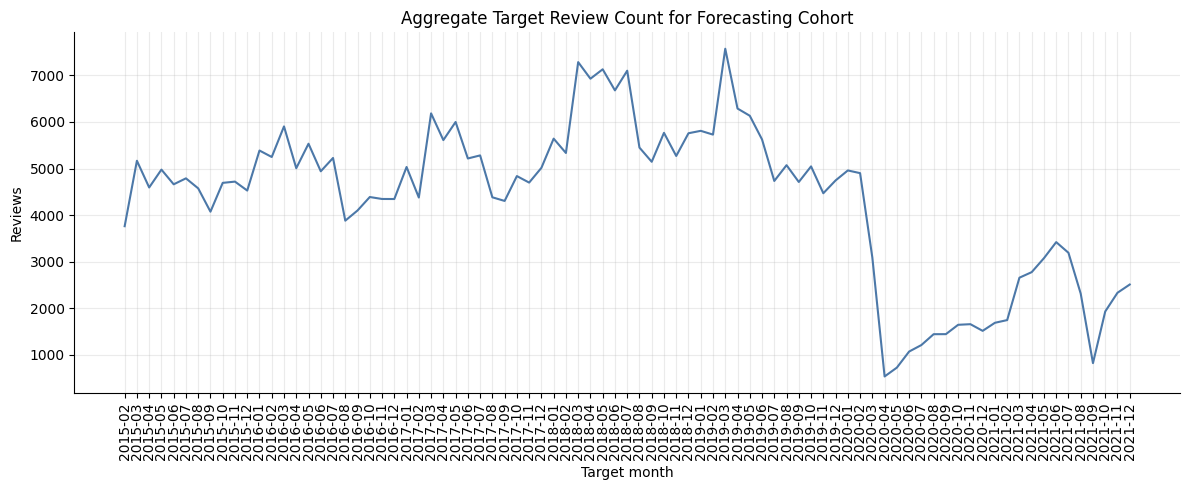

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\cohort_monthly_target_reviews.png


In [9]:
monthly_target = modeling.groupby("target_month_str")["target_next_month_reviews"].sum()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_target.index, monthly_target.values, color="#4C78A8")
ax.set_title("Aggregate Target Review Count for Forecasting Cohort")
ax.set_xlabel("Target month")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
path = FIGURES_DIR / "cohort_monthly_target_reviews.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

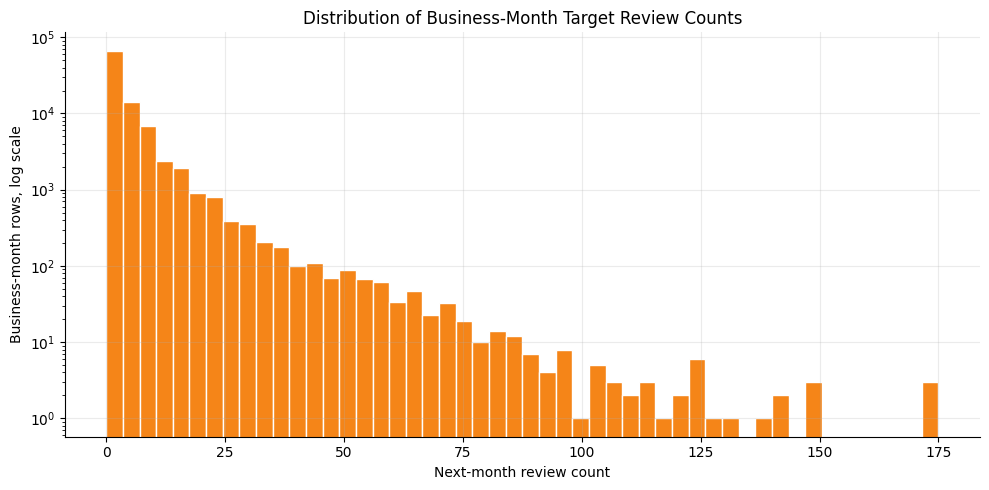

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\target_review_count_distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(modeling["target_next_month_reviews"], bins=50, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Business-Month Target Review Counts")
ax.set_xlabel("Next-month review count")
ax.set_ylabel("Business-month rows, log scale")
fig.tight_layout()
path = FIGURES_DIR / "target_review_count_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

## Interpretation

The resulting table directly represents the forecasting task. Historical features, static business metadata, and recent reviewer network features are available at feature month `t`; the target is month `t + 1`. This structure supports chronological evaluation and prevents future leakage.